# Лабораторная работа
# Ансамбли моделей машинного обучения. Часть 2
**Выполнил:** Хрипков Тимофей, группа ИУ5-65Б

## Описание задания
1. Выбрать набор данных для решения задачи классификации или регрессии.
2. Выполнить предобработку данных.
3. Разделить выборку на обучающую и тестовую.
4. Обучить модель стекинга и многослойного персептрона.
5. Оценить качество моделей и сравнить их.

## Выбор набора данных
Для выполнения работы выбран набор данных **Boston Housing** (цены на жильё в Бостоне).
Решается задача регрессии. Целевой признак — `MEDV` (медианная стоимость домов).

In [ ]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Настройка
import warnings
warnings.filterwarnings('ignore')

# Загрузка и первичный осмотр данных

In [ ]:
from sklearn.datasets import fetch_openml

# Загрузка данных Boston Housing (ID 531)
print("Загрузка данных Boston Housing...")
boston = fetch_openml(data_id=531, as_frame=True, parser='auto')
df = boston.frame

print(f"Размерность данных: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())

print("\nНазвания признаков:")
print(df.columns.tolist())

# Целевая переменная - MEDV
print(f"\nЦелевая переменная: MEDV (медианная стоимость домов)")
print(f"Статистика целевой переменной:")
print(df['MEDV'].describe())

Загрузка данных Boston Housing...
Размерность данных: (506, 14)

Первые 5 строк:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



Названия признаков:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Целевая переменная: MEDV (медианная стоимость домов)
Статистика целевой переменной:
count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


# Предобработка данных
Пропусков нет, категориальных признаков нет. Выполняется масштабирование данных и разделение на обучающую и тестовую выборки.

In [ ]:
# Отделяем признаки от целевой переменной
X = df.drop('MEDV', axis=1)
y = df['MEDV']

print(f"Размерность признаков: {X.shape}")
print(f"Пропуски в данных: {X.isnull().sum().sum()}")
print(f"Типы данных: все числовые")

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование (важно для MLP и линейных моделей в стекинге)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")

Размерность признаков: (506, 13)
Пропуски в данных: 0
Типы данных: все числовые

Размер обучающей выборки: 404 объектов
Размер тестовой выборки: 102 объектов


# Обучение модели стекинга
Используются алгоритмы RidgeCV и LassoCV в качестве базовых моделей.
В качестве финальной мета-модели применяется случайный лес.

In [ ]:
# Базовые модели (уровень 1)
estimators = [
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0])),
    ('lasso', LassoCV(alphas=[0.1, 1.0, 10.0], random_state=42, max_iter=10000))
]

# Мета-модель (уровень 2)
final_estimator = RandomForestRegressor(n_estimators=100, random_state=42)

# Создание и обучение стекинга
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5  # 5-кратная кросс-валидация
)

print("Обучение модели стекинга...")
stacking_model.fit(X_train_scaled, y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)
print("Модель стекинга обучена!")

Обучение модели стекинга...
Модель стекинга обучена!


# Обучение многослойного персептрона
Используется нейронная сеть прямого распространения с двумя скрытыми слоями на 100 и 50 нейронов.

In [ ]:
# Инициализация MLP
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

print("Обучение многослойного персептрона...")
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("Многослойный персептрон обучен!")
print(f"Количество итераций: {mlp_model.n_iter_}")

Обучение многослойного персептрона...
Многослойный персептрон обучен!
Количество итераций: 151


# Оценка качества моделей
Для оценки качества регрессионных моделей применяются метрики:
- **MAE** (средняя абсолютная ошибка)
- **RMSE** (среднеквадратичная ошибка)
- **R²** (коэффициент детерминации)


=== Сводная таблица результатов ===
               Model   MAE  RMSE    R2
            Stacking 3.196 4.760 0.691
MLP (Neural Network) 2.583 4.006 0.781


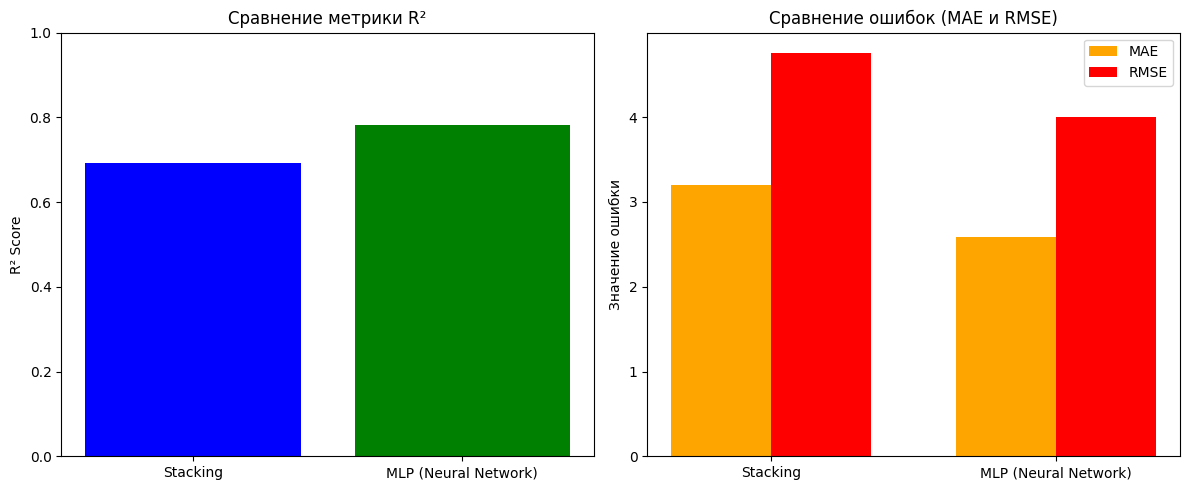

In [ ]:
# Функция для оценки модели
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    }

# Сбор результатов
results = [
    evaluate_model(y_test, y_pred_stack, "Stacking"),
    evaluate_model(y_test, y_pred_mlp, "MLP (Neural Network)")
]

results_df = pd.DataFrame(results)
print("\n=== Сводная таблица результатов ===")
print(results_df.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Сравнение R2
axes[0].bar(results_df['Model'], results_df['R2'], color=['blue', 'green'])
axes[0].set_title('Сравнение метрики R²')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)

# Сравнение ошибок
x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df['MAE'], width, label='MAE', color='orange')
axes[1].bar(x + width/2, results_df['RMSE'], width, label='RMSE', color='red')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'])
axes[1].set_title('Сравнение ошибок (MAE и RMSE)')
axes[1].set_ylabel('Значение ошибки')
axes[1].legend()

plt.tight_layout()
plt.show()

# Сравнение результатов моделей

## Полученные результаты

**Стекинг (Ridge + Lasso → Random Forest):**
- R² = 0.691
- MAE = 3.196
- RMSE = 4.760

**Многослойный персептрон (100 × 50 нейронов):**
- R² = 0.781
- MAE = 2.583
- RMSE = 4.006

## Сравнение

**По всем метрикам MLP оказался точнее стекинга:**
- R² выше на 9% (0.781 против 0.691)
- MAE меньше на 19% (2.583 против 3.196)
- RMSE меньше на 16% (4.006 против 4.760)

**Преимущества MLP:** выше точность, лучше выявляет нелинейные зависимости.

**Преимущества стекинга:** лучше интерпретируем, быстрее обучается.
